In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from collections import deque

import seaborn as sns
import yfinance as yf
import fredapi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from sklearn.svm import OneClassSVM

### Load dataset from Yahoo Finance and FRED API

In [3]:
# Define Start Date for Alignment
start_date = "2000-01-01"
end_date ="2025-01-01"

# Define tickers for Yahoo Finance API
index_tickers = ['SPY', '^VIX']
sector_tickers = ['XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLU', 'XLI', 'XLB', 'IYR', 'XLP']

# Get Market Index data
market_data = yf.download(index_tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']
market_data = market_data.rename(columns={'SPY': 'S&P500', 'QQQ': 'NASDAQ', 'DIA': 'DOW', '^VIX': 'VIX'})

# Compute SMA (50/200) & RSI (14-period)
market_data['SMA_50'] = market_data['S&P500'].rolling(window=50).mean()
market_data['SMA_200'] = market_data['S&P500'].rolling(window=200).mean()
market_data['SMA_Ratio'] = market_data['SMA_50'] / market_data['SMA_200']

delta = market_data['S&P500'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)

window = 14
avg_gain = pd.Series(gain, index=market_data.index).rolling(window=window, min_periods=1).mean()
avg_loss = pd.Series(loss, index=market_data.index).rolling(window=window, min_periods=1).mean()
rs = avg_gain / avg_loss
market_data['RSI'] = 100 - (100 / (1 + rs))

# Combine with sector_tickers
sector_data = yf.download(sector_tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']

# FRED Series
data_series = {
    'GDP': 'GDP',  # Quarterly GDP Growth
    'CPI': 'CPIAUCSL',  # Inflation (Consumer Price Index)
    'Unemployment': 'UNRATE',  # Unemployment Rate
    'FedFundsRate': 'FEDFUNDS',  # Federal Funds Rate
    '10Y Yield': 'DGS10',  # 10-Year Treasury Yield
    '2Y Yield': 'DGS2',  # 2-Year Treasury Yield
    '3M Yield': 'DGS3MO',  # 3-Month Treasury Yield
    'Consumer Sentiment': 'UMCSENT'  # Consumer Sentiment Index
}

# Fetch FRED Data (Trim to `start_date`)
fred = fredapi.Fred(api_key='YOUR_FRED_API_KEY')
fred_data = {name: fred.get_series(series_id, observation_start=start_date, observation_end=end_date) for name, series_id in data_series.items()}
# Convert dictionary to DataFrame
df_fred = pd.DataFrame(fred_data)
# Forward-fill missing values to align with daily market data
df_fred = df_fred.ffill()

# Convert 3M Treasury yield from annual % to daily return (divide by 100 for percentage)
df_fred['Daily_Cash_Return'] = (df_fred['3M Yield'] / 100) / 252

# Fill any remaining NaNs
df_fred['Daily_Cash_Return'] = df_fred['Daily_Cash_Return'].fillna(method='ffill')

# Build synthetic cash value curve (start at $1)
cash_index = (1 + df_fred['Daily_Cash_Return']).cumprod()
cash_index.name = 'CASH'

# Consolidate All Data
combined = pd.concat([market_data, sector_data, df_fred], axis=1)
combined['CASH'] = cash_index

In [4]:
df_fred

,GDP,CPI,Unemployment,FedFundsRate,10Y Yield,2Y Yield,3M Yield,Consumer Sentiment,Daily_Cash_Return
2000-01-01,10002.179,169.300,4.0,5.45,NaN,NaN,NaN,112.0,NaN
2000-01-03,10002.179,169.300,4.0,5.45,6.58,6.38,5.48,112.0,0.000217
2000-01-04,10002.179,169.300,4.0,5.45,6.49,6.30,5.43,112.0,0.000215
2000-01-05,10002.179,169.300,4.0,5.45,6.62,6.38,5.44,112.0,0.000216
2000-01-06,10002.179,169.300,4.0,5.45,6.57,6.35,5.41,112.0,0.000215
...,...,...,...,...,...,...,...,...,...
2024-12-26,29723.864,317.603,4.1,4.48,4.58,4.30,4.35,74.0,0.000173
2024-12-27,29723.864,317.603,4.1,4.48,4.62,4.31,4.31,74.0,0.000171
2024-12-30,29723.864,317.603,4.1,4.48,4.55,4.24,4.37,74.0,0.000173
2024-12-31,29723.864,317.603,4.1,4.48,4.58,4.25,4.37,74.0,0.000173


### Feature Engineering

In this step, we'll additional features to assist in regime detection

In [5]:
df = combined.copy()

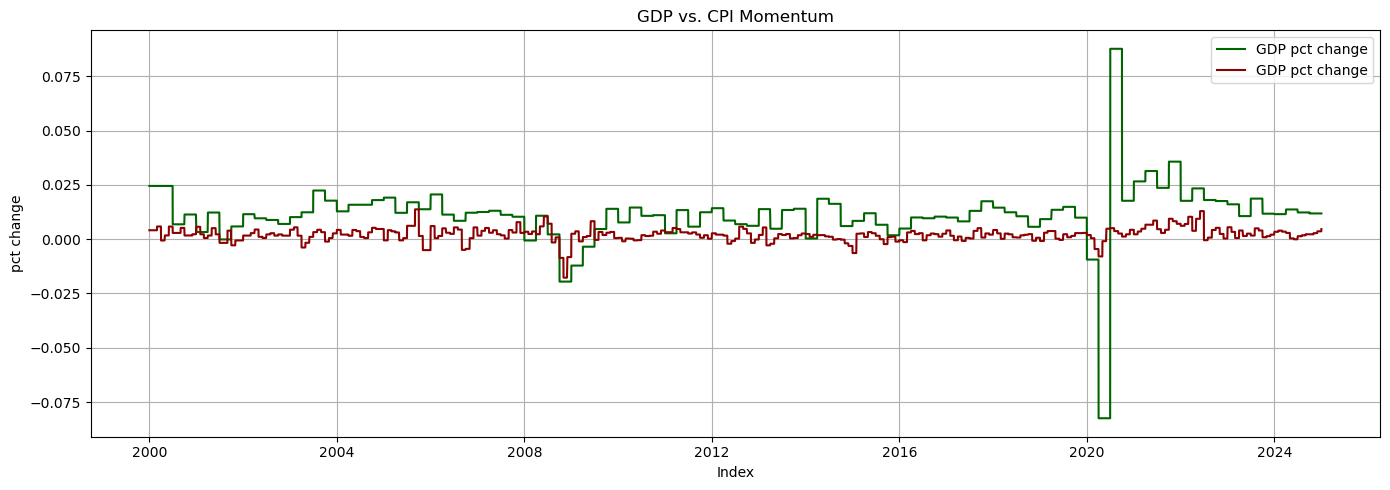

In [9]:
df['GDP_pct_change'] = df['GDP'].pct_change()
df['CPI_pct_change'] = df['CPI'].pct_change()

# Replace zeros with the previous non-zero value (forward-fill only the zeros)
df['GDP_pct_change'] = df['GDP_pct_change'].mask(df['GDP_pct_change'] == 0).ffill()
df['CPI_pct_change'] = df['CPI_pct_change'].mask(df['CPI_pct_change'] == 0).ffill()

# Optional: backfill the first row if still NaN
df['GDP_pct_change'] = df['GDP_pct_change'].bfill()
df['CPI_pct_change'] = df['CPI_pct_change'].bfill()

# Plot
plt.figure(figsize=(14, 5))

plt.plot(df['GDP_pct_change'], label='GDP pct change', color='darkgreen')
plt.plot(df['CPI_pct_change'], label='GDP pct change', color='darkred')

plt.title("GDP vs. CPI Momentum")
plt.ylabel("pct change")
plt.xlabel("Date" if df.index.name else "Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Golden/Death Cross indicator:
df['golden_cross'] = (df['SMA_50'] > df['SMA_200']).astype(int)

df['SP500_ret'] = df['S&P500'].pct_change()

for ticker in sector_tickers:
    df[f'{ticker}_ret'] = df[ticker].pct_change()
    
# Daily returns from the cash index
cash_returns = cash_index.pct_change().fillna(0)
cash_returns.name = 'CASH_ret'

# Add to df
df['CASH_ret'] = cash_returns
    
# Yield Curve (10Y - 2Y):
df['Yield_Curve'] = df['10Y Yield'] - df['2Y Yield']
df['Yield_Curve_10Y_3M'] = df['10Y Yield'] - df['3M Yield'] 

#### RSI (Relative Strength Index)
The RSI is a momentum oscillator that measures the speed and magnitude of recent price changes, typically on a scale from 0 to 100. It’s widely used to identify whether a security is overbought or oversold. In the context of regime analysis, RSI provides a snapshot of market strength. A high RSI (above 70) signals strong bullish momentum and potential overheating, while a low RSI (below 30) indicates weakening momentum or a market that may be oversold and due for a reversal. Across regimes, RSI helps differentiate between uptrending markets, sideways consolidations, and selloffs.

#### VIX (Volatility Index)
Often referred to as the “fear gauge,” the VIX reflects the market’s expectations for volatility over the next 30 days based on S&P 500 options pricing. It spikes during periods of uncertainty and market stress, and falls when markets are calm and confident. In regime identification, VIX is crucial because it helps flag high-risk periods. Low VIX readings (10–15) are common in steady bull markets, whereas elevated VIX levels (25+) typically signal panic, sharp corrections, or ongoing bear regimes. It’s a direct sentiment indicator that reflects investor anxiety or complacency.

#### SMA_Ratio (50-day / 200-day Moving Average Ratio)
The SMA_Ratio compares the short-term trend (50-day moving average) to the long-term trend (200-day moving average), and gives a normalized sense of trend direction. A ratio above 1 implies that prices are generally moving higher in the short run compared to the long run, which is a classic bullish sign. A ratio below 1 suggests that the market has turned bearish or is undergoing a correction. In regime clustering, this ratio helps distinguish between uptrending markets and declining or consolidating ones, especially when combined with other macro indicators.

####  Yield_Curve (10Y – 2Y Treasury Spread)
The yield curve is a classic macroeconomic indicator that measures the difference in yields between long-term (10-year) and short-term (2-year) government bonds. A normal, upward-sloping curve suggests optimism about future growth, while a flat or inverted curve (short-term yields > long-term) is considered a strong recession signal. In regime classification, a positive yield curve points to healthy economic expectations, while an inverted curve is typically associated with contraction regimes or upcoming downturns. It’s one of the earliest and most trusted signals of macro shifts.

#### Yield_Curve_10Y_3M (10-Year vs 3-Month Spread)
This version of the yield curve focuses on the short end of the curve by comparing the 10-year yield to the 3-month Treasury bill rate. It's even more sensitive to changes in central bank policy than the 10Y–2Y spread. A steep positive spread implies that markets expect future growth and inflation, while a negative spread (inversion) is an even more acute signal that the central bank has overtightened, increasing recession risk.

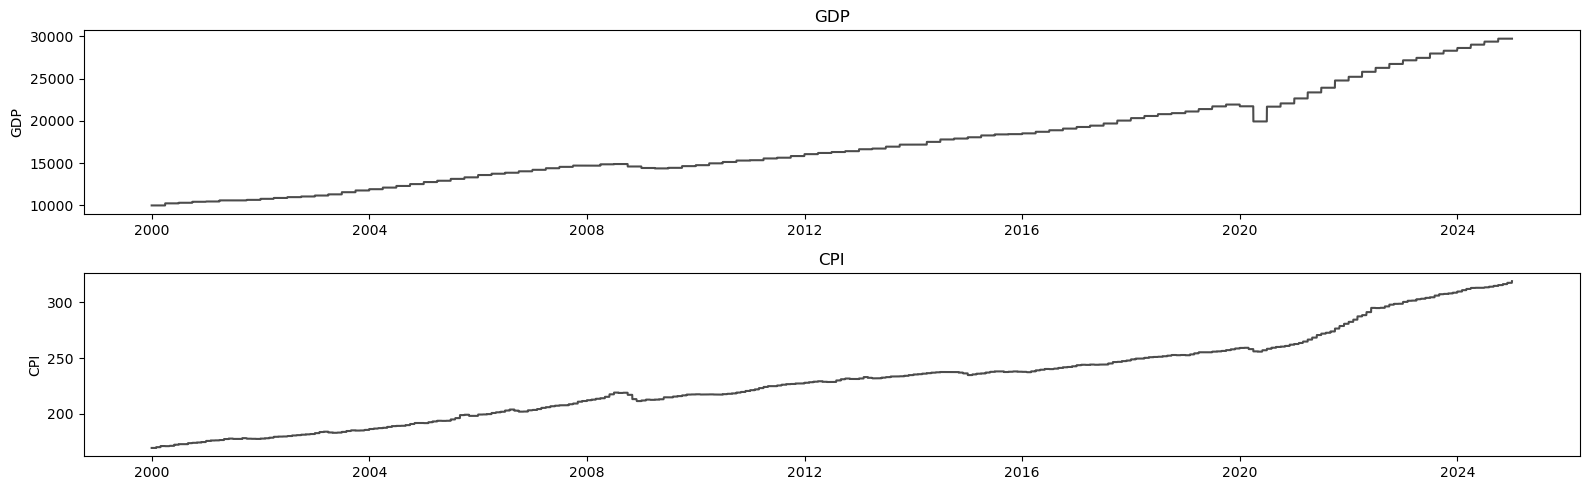

In [8]:
features = [
    'GDP', 'CPI'
]

import matplotlib.pyplot as plt

plt.figure(figsize=(16, len(features)*2.5))

for i, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    plt.plot(df[feature], color='black', alpha=0.7)
    plt.title(feature)
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

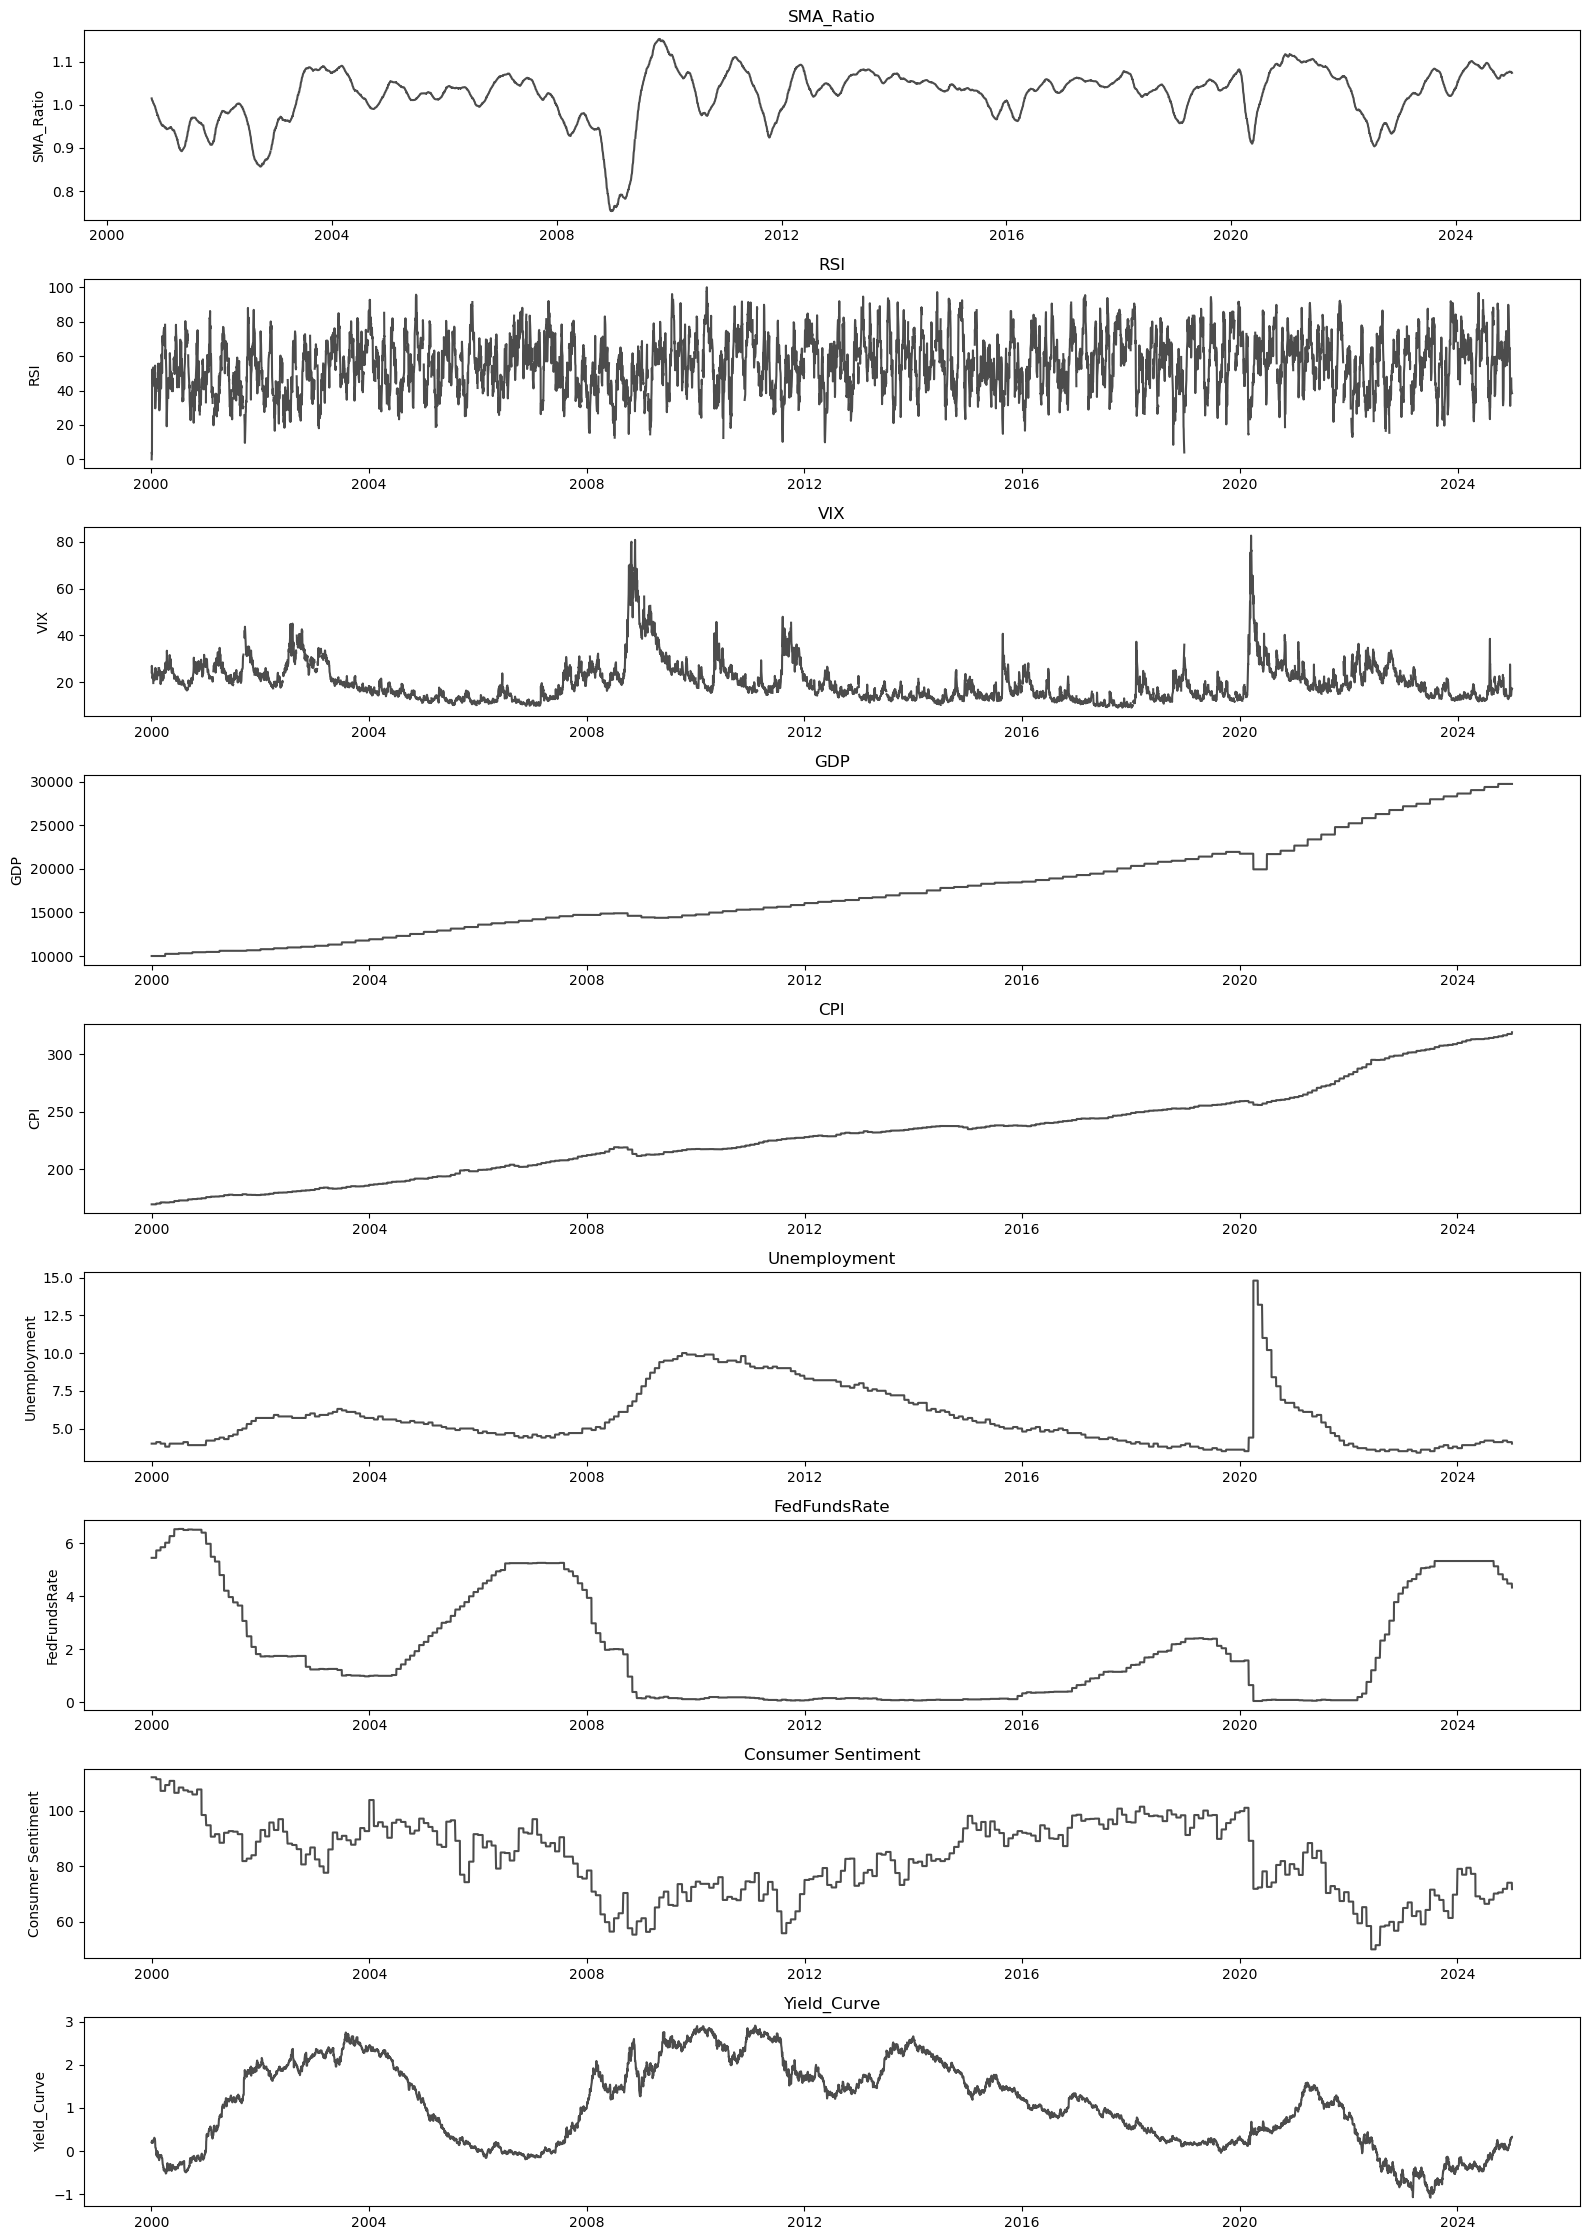

In [7]:
features = [
    'SMA_Ratio', 'RSI', 'VIX',
    'GDP', 'CPI', 'Unemployment', 'FedFundsRate', 'Consumer Sentiment',
    'Yield_Curve'
]

import matplotlib.pyplot as plt

plt.figure(figsize=(16, len(features)*2.5))

for i, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, i)
    plt.plot(df[feature], color='black', alpha=0.7)
    plt.title(feature)
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### Clustering using GMM

In [8]:
features = [
    'SMA_Ratio', 'RSI', 'VIX',
    'GDP_pct_change', 'CPI_pct_change', 'Unemployment', 'FedFundsRate', 'Consumer Sentiment',
    'Yield_Curve', 'Yield_Curve_10Y_3M',
    'SP500_ret', 'XLK_ret', 'XLF_ret', 'XLE_ret', 'XLV_ret', 'XLY_ret',
    'XLU_ret', 'XLI_ret', 'XLB_ret', 'IYR_ret', 'XLP_ret'
]


X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
pca = PCA(n_components=0.95)  
X_pca = pca.fit_transform(X_scaled)

In [10]:
n_components = 5
# Step 0: Fit the GMM
gmm = GaussianMixture(n_components=n_components, random_state=292)
gmm.fit(X_pca)  # ← This was missing!

# Step 1: Save raw GMM predictions
df['Raw_Regime'] = np.nan
df.loc[X.index, 'Raw_Regime'] = gmm.predict(X_pca)

# Step 2: Create smoothed regime using 5-day confirmation
raw_regimes = df.loc[X.index, 'Raw_Regime']
confirmed_regimes = []
buffer = deque(maxlen=4)  
current_regime = raw_regimes.iloc[0]

for regime in raw_regimes:
    buffer.append(regime)
    
    # If all 5 values in buffer match, and it's different from the current regime, lock it in
    if len(buffer) == 4 and all(x == buffer[0] for x in buffer) and buffer[0] != current_regime:
        current_regime = buffer[0]

    confirmed_regimes.append(current_regime)

# Step 3: Store smoothed version in a new column
df['Regime'] = np.nan
df.loc[X.index, 'Regime'] = confirmed_regimes

df['Regime'].value_counts()

Regime
4.0    2193
1.0    1330
0.0    1228
2.0    1065
3.0     274
Name: count, dtype: int64

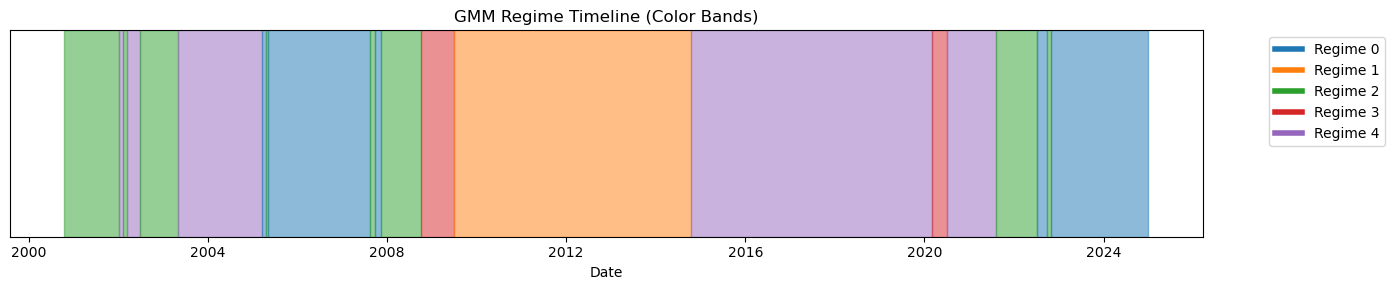

In [11]:
# Use a dynamic color palette
available_colors = list(mcolors.TABLEAU_COLORS.values())
if n_components > len(available_colors):
    raise ValueError("Not enough distinct colors for the number of regimes.")
colors = available_colors[:n_components]

# Ensure regime column is integer
df['Regime'] = df['Regime'].astype('Int64')

# Get regime series without NaNs
regime_series = df['Regime'].dropna()
prev_regime = regime_series.iloc[0]
start_date = regime_series.index[0]

# Plot
plt.figure(figsize=(14, 3))
plt.title("GMM Regime Timeline (Color Bands)")

for date, regime in regime_series.items():
    if regime != prev_regime:
        plt.axvspan(start_date, date, color=colors[int(prev_regime)], alpha=0.5, label=f'Regime {prev_regime}')
        start_date = date
        prev_regime = regime

# Fill the final region
plt.axvspan(start_date, regime_series.index[-1], color=colors[int(prev_regime)], alpha=0.5, label=f'Regime {prev_regime}')

# Legend cleanup
handles = [plt.Line2D([0], [0], color=colors[i], lw=4) for i in range(n_components)]
labels = [f"Regime {i}" for i in range(n_components)]
plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Date")
plt.yticks([])
plt.tight_layout()
plt.show()

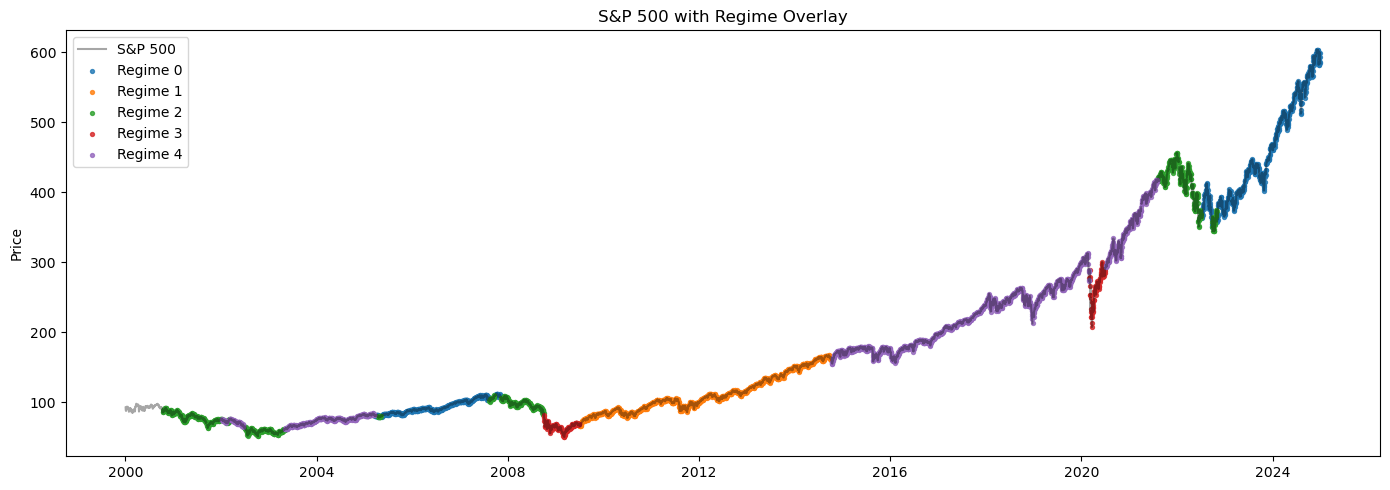

In [12]:
plt.figure(figsize=(14, 5))

# Plot the S&P500 line in faint black
plt.plot(df['S&P500'], label='S&P 500', color='black', alpha=0.35)

# Use the same dynamic color palette
colors = available_colors[:n_components]

# Overlay each regime with scatter dots
for i in range(n_components):
    mask = df['Regime'] == i
    plt.scatter(df.index[mask], df['S&P500'][mask], color=colors[i], label=f'Regime {i}', s=8, alpha=0.8)

plt.title("S&P 500 with Regime Overlay")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


### Cluster Interpretation

In [13]:
# Define feature groups
sentiment_features = ['RSI', 'VIX', 'SMA_Ratio']
macro_features = ['Yield_Curve', 'Yield_Curve_10Y_3M']
sector_return_cols = [col for col in df.columns if col.endswith('_ret')]

# Create SMA difference feature
df['SMA_diff'] = df['SMA_50'] - df['SMA_200']

# Combine all relevant features
fred_features = sentiment_features + ['SMA_diff'] + macro_features 
yahoo_features = sector_return_cols

# Drop rows where Regime is missing
df_clean = df.dropna(subset=['Regime'])

# Group by regime and calculate median
fred_summary_median = df_clean.groupby('Regime')[fred_features].median()
yahoo_summary_median = df_clean.groupby('Regime')[yahoo_features].median()

# Calculate % of positive returns per sector per regime
positive_return_pct = df_clean[sector_return_cols + ['Regime']].copy()
for col in sector_return_cols:
    positive_return_pct[col] = positive_return_pct[col] > 0

positive_return_pct_summary = positive_return_pct.groupby('Regime')[sector_return_cols].mean() * 100

In [14]:
fred_summary_median

,RSI,VIX,SMA_Ratio,SMA_diff,Yield_Curve,Yield_Curve_10Y_3M
Regime,,,,,,
0,58.857016,14.110000,1.039344,4.892981,-0.08,-0.320
1,58.258416,17.580000,1.056624,6.676443,2.25,2.580
2,47.849902,25.059999,0.962449,-3.616726,1.22,1.760
3,52.285687,42.250000,0.887144,-13.953241,1.85,2.575
4,57.449112,15.650000,1.041193,6.041144,1.05,1.540


In [15]:
yahoo_summary_median

,SP500_ret,XLK_ret,XLF_ret,XLE_ret,XLV_ret,XLY_ret,XLU_ret,XLI_ret,XLB_ret,IYR_ret,XLP_ret,CASH_ret
Regime,,,,,,,,,,,,
0,0.000716,0.001273,0.000895,0.001205,0.000283,0.000668,0.001087,0.000927,0.000964,0.000318,0.000644,0.000194
1,0.000840,0.001046,0.000739,0.000682,0.000837,0.001326,0.000748,0.000967,0.001043,0.000915,0.000834,0.000003
2,0.000435,-0.000840,-0.000764,0.001335,0.000731,0.000355,0.000579,0.000289,-0.000235,0.000656,0.000260,0.000068
3,0.000814,0.002367,-0.004176,0.002226,0.000763,0.000978,-0.000085,0.000895,0.003578,-0.002652,0.000856,0.000007
4,0.000603,0.001092,0.000699,0.000167,0.000722,0.001051,0.001237,0.000782,0.000754,0.001229,0.000438,0.000038


In [16]:
positive_return_pct_summary

,SP500_ret,XLK_ret,XLF_ret,XLE_ret,XLV_ret,XLY_ret,XLU_ret,XLI_ret,XLB_ret,IYR_ret,XLP_ret,CASH_ret
Regime,,,,,,,,,,,,
0,55.048860,55.048860,52.687296,53.664495,50.732899,52.117264,53.990228,54.153094,52.931596,50.977199,51.872964,100.000000
1,56.691729,55.413534,52.932331,52.556391,54.661654,55.563910,52.556391,54.360902,53.984962,53.458647,55.488722,99.624060
2,51.267606,47.887324,48.075117,52.206573,51.549296,50.610329,51.267606,50.516432,49.107981,52.300469,50.328638,100.000000
3,52.919708,52.919708,47.080292,54.379562,51.094891,50.729927,49.270073,52.189781,56.204380,48.540146,51.459854,98.175182
4,54.901961,54.582763,52.257182,50.296398,53.214774,54.400365,55.129959,53.807570,53.077975,56.178751,52.302782,99.498404


#### Regime 0: Moderate Expansion
- **Market Sentiment**:
  - RSI around 58–59 suggests stable upward momentum.
  - VIX is low (~14), implying calm and low volatility.
  - `SMA_Ratio > 1` and `SMA_diff ~4.89` → market trend is bullish, but not euphoric.

- **Macro Backdrop**:
  - Yield Curve is slightly **inverted** (-0.08), and 10Y–3M is also negative (–0.32).
  - This implies the economy is **late cycle**, where the market is still strong but bond markets are hinting at a future slowdown or policy mistake.

- **Interpretation**:  
  A steady-growth environment with market confidence and strong technicals, but some **underlying macro risk**.  
  Possibly the tail end of a bull market — a "goldilocks" phase before things roll over.


#### Regime 1: Bullish Risk-On
- **Market Sentiment**:
  - RSI remains strong (~58), `SMA_diff` jumps to ~6.7 (higher than Regime 0).
  - `SMA_Ratio > 1.05`, VIX starts ticking up (~17.6) — bullish but slightly more volatile.

- **Macro Backdrop**:
  - Both yield curve and 10Y–3M are **steeply positive** (2.25 and 2.58 respectively).
  - This is a classic early- to mid-expansion signal, where policy is loose, and future growth expectations are strong.

- **Interpretation**:  
  This is a **textbook "risk-on" regime**. Fundamentals and sentiment align, and both equity and macro signals show strength. Possibly follows a major recovery or easing cycle.
  

#### Regime 2: Choppy Recovery
- **Market Sentiment**:
  - RSI remains strong (~58), `SMA_diff` jumps to ~6.7 (higher than Regime 0).
  - `SMA_Ratio > 1.05`, VIX starts ticking up (~17.6) — bullish but slightly more volatile.

- **Macro Backdrop**:
  - Both yield curve and 10Y–3M are **steeply positive** (2.25 and 2.58 respectively).
  - This is a classic early- to mid-expansion signal, where policy is loose, and future growth expectations are strong.

- **Interpretation**:  
  This is a **textbook "risk-on" regime**. Fundamentals and sentiment align, and both equity and macro signals show strength. Possibly follows a major recovery or easing cycle.
  
#### Regime 3: Panic or Market Correction
- **Market Sentiment**:
  - RSI drops to ~47.8, `SMA_Ratio` dips below 1 (0.96), and `SMA_diff` is negative (–3.6) → technical weakness
  - VIX jumps to ~25 → elevated volatility and investor anxiety

- **Macro Backdrop**:
  - Yield curve and 10Y–3M are both positive (1.22 and 1.76), suggesting supportive macro fundamentals.

- **Interpretation**:  
  Market is **under stress**, likely recovering from a correction or external shock. Macro conditions remain solid (no inversion), but sentiment is fragile. Sector dispersion is high — risk of whipsaws.
  
#### Regime 4: Recovery and Stabilization
- **Market Sentiment**:
  - RSI (around 57.4), `SMA_Ratio` (around 1.04), `SMA_diff` (around 6.0) all bounce back toward bullish levels.
  - VIX declines again to ~15.6, reflecting reduced fear.

- **Macro Backdrop**:
  - Yield curve is still **modestly positive** (1.05 and 1.54), showing policy support and stabilizing expectations.

- **Interpretation**:  
  This regime follows a drawdown or slowdown — **sentiment is rebuilding**, and macro conditions are supportive. This phase offers a clean entry point after fear recedes, marking early bull recovery.
  
  
#### Cluster Labels and Summary
  
 
| Regime | Label                    | Sentiment                   | Macro                     | Suggested Strategy                        |
|--------|--------------------------|-----------------------------|---------------------------|-------------------------------------------|
| 0      | Moderate Expansion       | Calm, steady uptrend        | Slight inversion warning  | Long equities, monitor cracks             |
| 1      | Bullish Risk-On          | Strong momentum             | Steep yield curve         | Go aggressive on growth, tech             |
| 2      | Choppy Recovery          | Weak trend, high VIX        | Supportive macro          | Be selective, defensive tilt              |
| 3      | Panic / Market Correction| Sharp breakdown, VIX 40+    | Macro not yet inverted    | De-risk, wait out the chaos               |
| 4      | Recovery and Stabilization | Trend returning            | Macro still positive      | Re-risk slowly, favor quality + cyclicals |



In [17]:
# Step 1: Define your regime label mapping
regime_labels = {
    0: 'Moderate Expansion',
    1: 'Bullish Risk-On',
    2: 'Choppy Recovery',
    3: 'Panic / Correction',
    4: 'Recovery Phase'
}

# Step 2: Add the label as a new column based on Regime
df_clean = df_clean.copy()
df_clean['Regime_Label'] = df_clean['Regime'].map(regime_labels)

###  Compute Average Sector Returns per Regime

In [18]:
# List of sector return columns
sector_ret_cols = [
    'XLK_ret', 'XLF_ret', 'XLE_ret', 'XLV_ret', 'XLY_ret',
    'XLU_ret', 'XLI_ret', 'XLB_ret', 'IYR_ret', 'XLP_ret'
]

# Sector name mapping
sector_labels = {
    'XLK_ret': 'Technology (XLK)',
    'XLF_ret': 'Financials (XLF)',
    'XLE_ret': 'Energy (XLE)',
    'XLV_ret': 'Healthcare (XLV)',
    'XLY_ret': 'Cons. Discretionary (XLY)',
    'XLU_ret': 'Utilities (XLU)',
    'XLI_ret': 'Industrials (XLI)',
    'XLB_ret': 'Materials (XLB)',
    'IYR_ret': 'Real Estate (IYR)',
    'XLP_ret': 'Cons. Staples (XLP)'
}

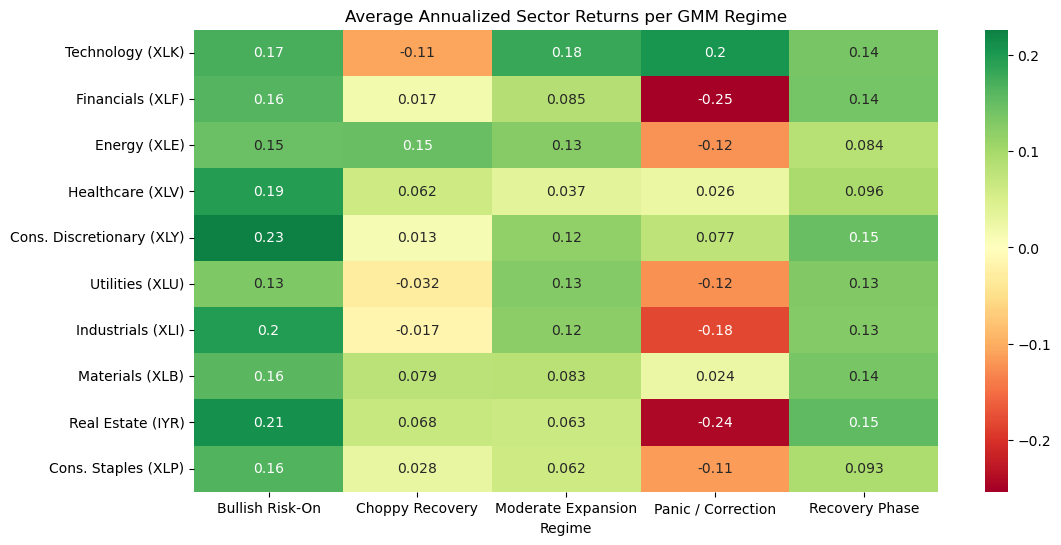

In [19]:
# Group by regime and compute mean daily returns per sector
regime_sector_perf = df_clean.groupby('Regime_Label')[sector_ret_cols].mean().T

# Multiply by 252 to annualize returns
regime_sector_perf_annualized = regime_sector_perf * 252

# Relabel index with descriptive sector names
regime_sector_perf_annualized.index = [sector_labels[t] for t in regime_sector_perf_annualized.index]

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(regime_sector_perf_annualized, annot=True, cmap='RdYlGn', center=0)
plt.title("Average Annualized Sector Returns per GMM Regime")
plt.xlabel("Regime")
plt.show()


###  Annualized Sector Volatility per Regime

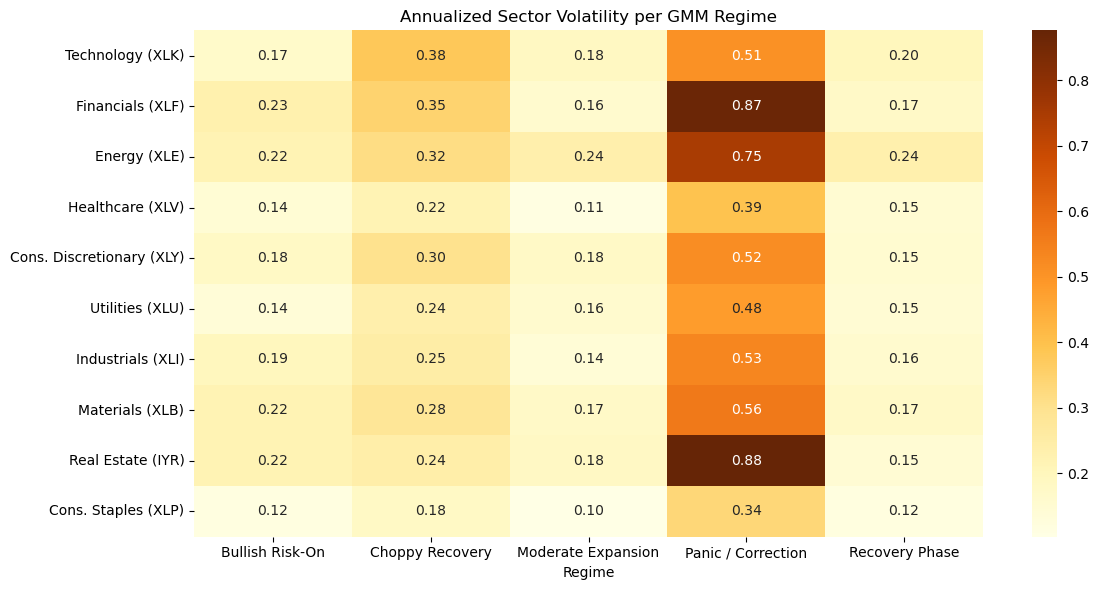

In [20]:
# Volatility (annualized)
regime_sector_vol = df_clean.groupby('Regime_Label')[sector_ret_cols].std().T * np.sqrt(252)

# Replace index with sector names
regime_sector_vol.index = [sector_labels[ticker] for ticker in regime_sector_vol.index]

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(regime_sector_vol, annot=True, fmt=".2f", cmap='YlOrBr', center=None)
plt.title("Annualized Sector Volatility per GMM Regime")
plt.xlabel("Regime")
plt.tight_layout()
plt.show()

### Sharpe Ratio per Regime

The Sharpe ratio is a widely used measure of risk-adjusted return, calculated as the mean return divided by the standard deviation of returns. However, when computed on a daily dataset without any scaling, the result is a daily Sharpe ratio, which only reflects risk-adjusted performance per day. While this is mathematically correct, it is not easily interpretable or directly comparable to the Sharpe ratios commonly reported by fund managers, financial analysts, or in academic literature, most of which are presented on an annualized basis.

To make the Sharpe ratio comparable across different strategies and investment horizons, it is standard practice to annualize it. When working with daily returns, this is done by multiplying the daily Sharpe ratio by the square root of 252 (the approximate number of trading days in a year). This scaling assumes that returns are independently and identically distributed, and it expresses how much excess return is expected per unit of risk over a full year. The annualized Sharpe ratio provides a more intuitive understanding of performance and is a critical metric in portfolio optimization, strategy evaluation, and fund benchmarking.

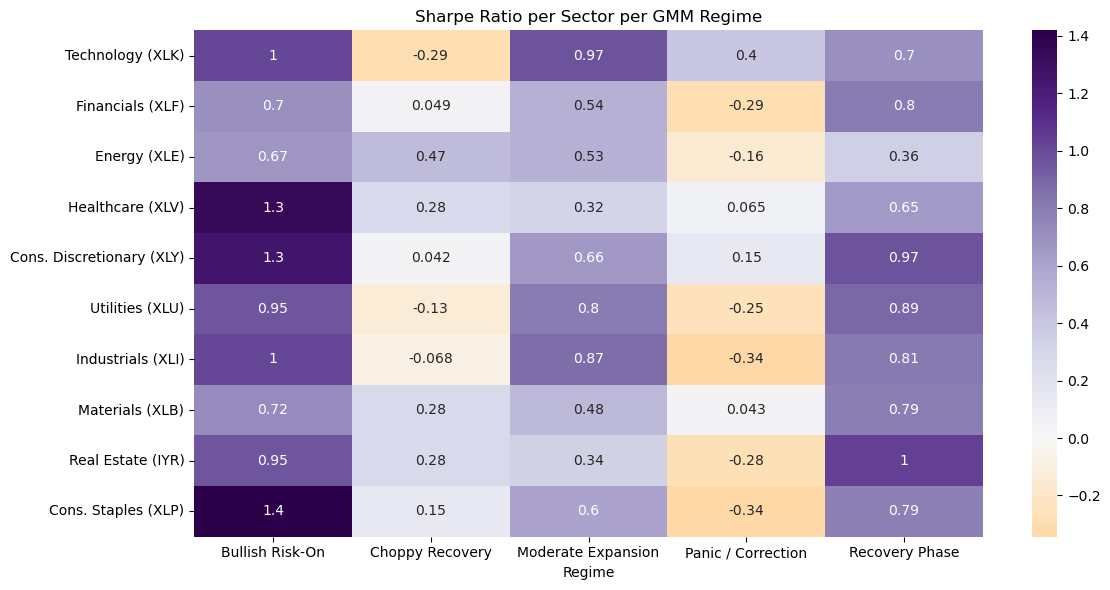

In [21]:
# Calculate annualized mean return and std dev
sector_mean = df_clean.groupby('Regime_Label')[sector_ret_cols].mean().T * 252
sector_std = df_clean.groupby('Regime_Label')[sector_ret_cols].std().T * np.sqrt(252)

# Calculate Sharpe Ratio (no risk-free rate subtracted here)
regime_sector_sharpe = sector_mean / sector_std

# Rename index to sector names
regime_sector_sharpe.index = [sector_labels[t] for t in regime_sector_sharpe.index]

# Plot Sharpe Ratio heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(regime_sector_sharpe, annot=True, cmap='PuOr', center=0)
plt.title("Sharpe Ratio per Sector per GMM Regime")
plt.xlabel("Regime")
plt.tight_layout()
plt.show()

### Sector Allocation Strategy

This allocation strategy is designed to dynamically shift portfolio weights across sector ETFs based on their historical risk-adjusted performance under different market regimes. Using a Gaussian Mixture Model (GMM), the market is segmented into distinct regimes such as "Bullish Risk-On" or "Panic/Correction." For each regime, we calculate the annualized Sharpe ratio for every sector, which measures the average excess return per unit of volatility. These Sharpe ratios are then used to guide how capital should be distributed, with higher weights assigned to sectors that have historically delivered stronger performance relative to their risk during similar market conditions.

To reduce overfitting and increase robustness, we implement a **Sharpe Bucketing** approach instead of directly normalizing Sharpe Ratios into weights. For each regime, all sector ETFs (including cash) are ranked by their regime-specific Sharpe Ratios. We then assign allocations based on fixed tiers:

- The **top 3 sectors** receive **70% of the portfolio** (split as 24%, 23%, and 23%),
- The **next 3 sectors** receive **30%** (10% each),
- The **remaining sectors** are assigned **zero weight**.

This method avoids overreacting to small differences in Sharpe Ratios and helps maintain diversification.

To ensure that all weights still sum to 100%, we normalize the weights vector within each regime using the following formula:

$$
\text{Final Weight}_i = \frac{\text{Assigned Weight}_i}{\sum_j \text{Assigned Weight}_j}
$$

This guarantees that:

$$
\sum_{i=1}^{n} \text{Final Weight}_i = 1
$$

where *n* is the number of sectors (including `CASH_ret` when applicable). This strategy ensures consistent capital deployment across regimes while smoothing over noisy Sharpe estimates.


In [38]:
# Step 1: Select all sector return columns INCLUDING 'CASH_ret'
sector_cols = [col for col in df.columns if col.endswith('_ret') and col != 'SP500_ret']

# Step 2: Compute annualized mean and std
sector_mean = df_clean.groupby('Regime_Label')[sector_cols].mean().T * 252
sector_std = df_clean.groupby('Regime_Label')[sector_cols].std().T * np.sqrt(252)

# Step 3: Compute Sharpe ratio
regime_sector_sharpe = sector_mean / sector_std

# Step 4: Copy for allocation logic
sector_sharpe_df = regime_sector_sharpe.copy()

# Step 5: Clip negative Sharpe values (optional)
sector_sharpe_df = sector_sharpe_df.clip(lower=0)

# Step 6: Normalize weights per regime (Option A — restrict CASH_ret)
allocation_df = pd.DataFrame(index=sector_sharpe_df.index)

for regime_name in sector_sharpe_df.columns:
    sharpe_vals = sector_sharpe_df[regime_name].copy()

    # Zero out cash except during panic regime
    if regime_name != 'Panic / Correction' and 'CASH_ret' in sharpe_vals.index:
        sharpe_vals.loc['CASH_ret'] = 0

    # Rank Sharpe values in descending order
    ranked = sharpe_vals.sort_values(ascending=False)

    # Assign tiers
    top_3 = ranked.head(3).index
    mid_3 = ranked.iloc[3:6].index

    weights = pd.Series(0, index=sharpe_vals.index)
    weights[top_3] = [0.24, 0.23, 0.23]
    weights[mid_3] = 0.10  # Equal split of remaining 30%

    # Normalize just in case of fewer than 6 valid sectors
    weights = weights / weights.sum()

    allocation_df[regime_name] = weights

allocation_df = allocation_df.round(4)
allocation_df

,Bullish Risk-On,Choppy Recovery,Moderate Expansion,Panic / Correction,Recovery Phase
XLK_ret,0.10,0.00,0.24,0.23,0.00
XLF_ret,0.00,0.10,0.10,0.10,0.10
XLE_ret,0.00,0.24,0.00,0.00,0.00
XLV_ret,0.23,0.23,0.00,0.10,0.00
XLY_ret,0.23,0.00,0.10,0.23,0.23
XLU_ret,0.10,0.00,0.23,0.00,0.23
XLI_ret,0.10,0.00,0.23,0.00,0.10
XLB_ret,0.00,0.10,0.00,0.10,0.10
IYR_ret,0.00,0.23,0.00,0.00,0.24
XLP_ret,0.24,0.10,0.10,0.00,0.00


### Perform Backtest with Initial Capital of $100,000

In [39]:
df_testing = df.copy()

In [40]:
initial_capital = 100_000  # starting with $100K
portfolio_value = [initial_capital]

In [41]:
# Map the regime number to column name
regime_map = {
    0: 'Bullish Risk-On',
    1: 'Choppy Recovery',
    2: 'Moderate Expansion',
    3: 'Panic / Correction',
    4: 'Recovery Phase'
}

In [42]:
# # This is based on your allocation_df row index format
# sector_mapping = {
#     'Technology (XLK)': 'XLK_ret',
#     'Financials (XLF)': 'XLF_ret',
#     'Energy (XLE)': 'XLE_ret',
#     'Healthcare (XLV)': 'XLV_ret',
#     'Cons. Discretionary (XLY)': 'XLY_ret',
#     'Utilities (XLU)': 'XLU_ret',
#     'Industrials (XLI)': 'XLI_ret',
#     'Materials (XLB)': 'XLB_ret',
#     'Real Estate (IYR)': 'IYR_ret',
#     'Cons. Staples (XLP)': 'XLP_ret'
    
# }

# allocation_df.index = allocation_df.index.map(sector_mapping)

In [44]:
# Get list of sector columns (e.g., ['XLK_ret', 'XLF_ret', ...])
sector_cols = allocation_df.index.tolist()

# Initialize a list to store daily portfolio values
portfolio_value = [initial_capital]

# Loop through each row (daily observation) starting from when regime is known
for i in range(1, len(df)):
    current_regime = df['Regime'].iloc[i]

    if pd.isna(current_regime):
        portfolio_value.append(portfolio_value[-1])
        continue

    regime_name = regime_map[int(current_regime)]

    if regime_name not in allocation_df.columns:
        portfolio_value.append(portfolio_value[-1])
        continue

    weights = allocation_df[regime_name]
    
    todays_returns = df.iloc[i][sector_cols].fillna(0)
    
    daily_return = (weights * todays_returns).sum()
    new_value = portfolio_value[-1] * (1 + daily_return)
    portfolio_value.append(new_value)

In [45]:
df_testing = df_testing.iloc[1:].copy()  # drop the first row (no return applied)
df_testing['Portfolio_Value'] = portfolio_value[1:]  # align with df index

In [46]:
# Create new column to track SP500 value
df_testing['SP500_Value'] = initial_capital * (1 + df_testing['SP500_ret'].fillna(0)).cumprod()

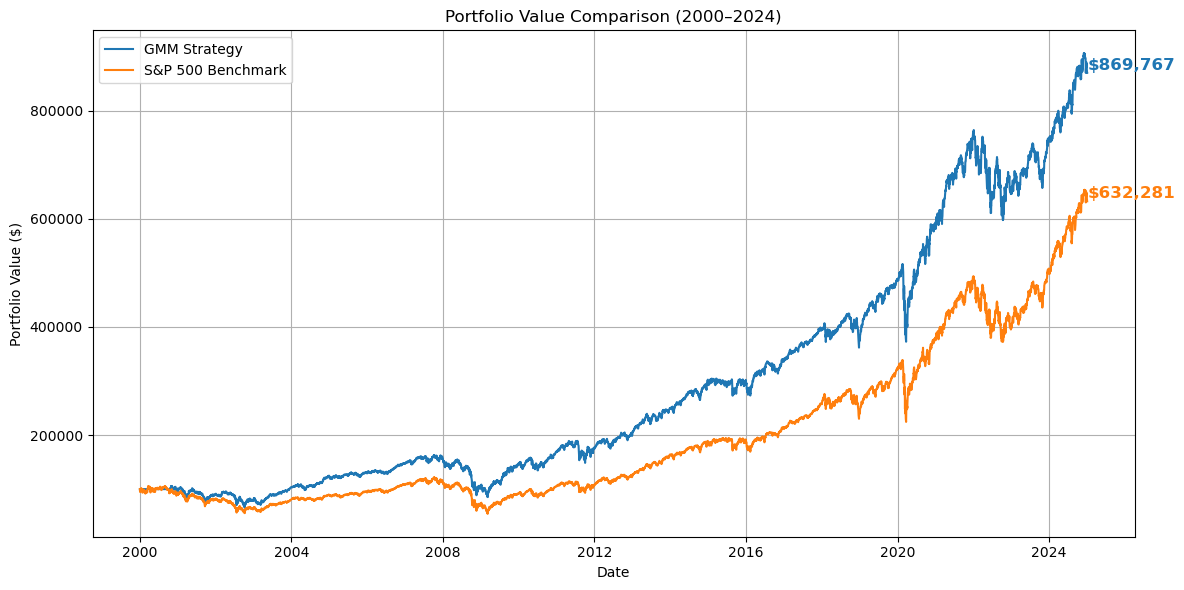

In [50]:
plt.figure(figsize=(12, 6))

# Plot both strategies and capture the line objects
gmm_line, = plt.plot(df_testing.index, df_testing['Portfolio_Value'], label='GMM Strategy', color='tab:blue')
sp500_line, = plt.plot(df_testing.index, df_testing['SP500_Value'], label='S&P 500 Benchmark', color='tab:orange')

# Get final values
final_date = df_testing.index[-1]
gmm_final = df_testing['Portfolio_Value'].iloc[-1]
sp500_final = df_testing['SP500_Value'].iloc[-1]

# Annotate with matching colors, bigger and bold
plt.text(final_date, gmm_final, f"${gmm_final:,.0f}",
         color=gmm_line.get_color(), fontsize=12, fontweight='bold', va='bottom')
plt.text(final_date, sp500_final, f"${sp500_final:,.0f}",
         color=sp500_line.get_color(), fontsize=12, fontweight='bold', va='bottom')

# Labels and styling
plt.title("Portfolio Value Comparison (2000–2024)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



The low correlation between the GMM strategy and each individual sector ETF indicates that the portfolio does not closely track any single sector. This is a positive outcome, as it suggests that the strategy is well-diversified and not disproportionately influenced by any one industry. It also confirms that the Sharpe ratio–based allocation mechanism is spreading exposure across multiple sectors rather than simply mimicking a single ETF's behavior. In effect, the strategy leverages regime-specific signals to adapt its composition dynamically, which helps reduce concentration risk.

Despite this, the GMM strategy still exhibits a high correlation with the overall S&P 500 index. This is not surprising, as the strategy is fully allocated to equities and reacts to the same macroeconomic forces that drive the broader market — such as interest rate shifts, economic cycles, and volatility regimes. Additionally, since the S&P 500 index itself is composed of many of the same sector ETFs included in the strategy, the general performance trends will naturally align. To further differentiate the strategy, enhancements like introducing cash or bond allocations during risk-off regimes could help reduce its dependency on equity market direction.